In [180]:
import pandas as pd
import numpy as np
import os
from sklearn import svm
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import scale
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import \
    train_test_split, StratifiedShuffleSplit, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score


from matrix_processor import MatrixProcessor
import warnings
warnings.filterwarnings('ignore')

In [181]:
manifest = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/manifest/Cristiano_manifest.csv')
gc_content = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/processing/gc_content_per_region.csv')
if 'length' in gc_content.columns:
    gc_content = gc_content.drop(columns=['length'])
# need to transpose gc_content to have features as columns and regions as rows
gc_content = gc_content.set_index('region_id').T
sample_ids = manifest['seqrun_id'].apply(lambda x: f'EE{x}').values
metadata_cols = ['sample_name', 'stage', 'disease', 'tissue', 'cancer_true']

print(f"Total samples: {len(sample_ids)}")
print(f"head: {sample_ids[:5]}")


Total samples: 459
head: <StringArray>
['EE87786', 'EE87787', 'EE87788', 'EE87789', 'EE87790']
Length: 5, dtype: str


In [71]:
# old
# Function to load from individual files, flattening first
def load_from_individuals(feature_name, sample_ids):
    """Load feature matrix from individual sample files"""
    features_path = '/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/cristiano_features/'
    rows = []
    
    for i, sample_id in enumerate(sample_ids):
        if i % 50 == 0:
            print(f"Loading {i+1}/{len(sample_ids)}...")
        
        file_path = f"{features_path}{feature_name}/{sample_id}_{feature_name}.csv"
        df = pd.read_csv(file_path, index_col=0)
        
        values = df.values.flatten()
        rows.append(values)
    
    X = np.array(rows)
    return X


In [182]:
length_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_length.csv"
pfe_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_pfe.csv"
edm_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_edm.csv"

## PANCAN model - healthy vs cancer

## Length

Splitting the data into train and test  

In [188]:
df = pd.read_csv(length_path)
print(f"Cancer types: {df['disease'].unique()}")
df_length = df.drop(columns=['seqrun_id']).set_index('sample_id')
df_length['cancer_true'] = df_length['disease'].apply(lambda x: 0 if x == 'Healthy' else 1)
print(df['disease'].value_counts())
print(df_length['disease'].unique())
X_length = df_length.drop(columns=metadata_cols)
y_length = df_length['cancer_true']

# preprocessing:
# standardize and GC correct
matrix_processor = MatrixProcessor(mx = X_length, gc_file=gc_content)
X_length = matrix_processor.standardize()


Cancer types: <StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str
disease
Healthy              246
Breast cancer         53
Pancreatic cancer     35
Ovarian cancer        28
Colorectal cancer     27
Bile duct cancer      25
Gastric cancer        24
Lung cancer           20
Duodenal cancer        1
Name: count, dtype: int64
<StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str


In [186]:
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

auc_scores = []

# For meta-matrix: collect held-out probabilities from first CV pass only
meta_probs = np.full(len(y_length), np.nan)

for fold_i, (train_idx, test_idx) in enumerate(rskf.split(X_length, y_length)):
    X_train = X_length.iloc[train_idx]
    X_test = X_length.iloc[test_idx]
    y_train = y_length.iloc[train_idx]
    y_test = y_length.iloc[test_idx]
    
    model = svm.SVC(probability=True)
    model.fit(X_train, y_train)
    
    # Probability of class 1 (healthy) — we want P(cancer) for IFP score
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # AUC: sklearn handles direction automatically
    auc = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)
    
    # First 10 folds = first complete CV pass → store for meta-matrix
    if fold_i < 10:
        meta_probs[test_idx] = y_prob

# ── 4. Report results ───────────────────────────────────────
mean_auc = np.mean(auc_scores)
ci_lower = np.percentile(auc_scores, 2.5)
ci_upper = np.percentile(auc_scores, 97.5)

print(f"\nLength PANCAN AUC: {mean_auc:.4f} (95% CI: {ci_lower:.4f} - {ci_upper:.4f})")
print(f"Zhou benchmark:     0.8741 (95% CI: 0.8634 - 0.8848)")

# Sanity check: every sample got a held-out probability
assert not np.any(np.isnan(meta_probs)), "Some samples missing held-out probabilities!"
print(f"\nMeta-matrix column ready: {meta_probs.shape[0]} probabilities collected")


Length PANCAN AUC: 0.8409 (95% CI: 0.7292 - 0.9439)
Zhou benchmark:     0.8741 (95% CI: 0.8634 - 0.8848)

Meta-matrix column ready: 459 probabilities collected


In [187]:
se = np.std(auc_scores) / np.sqrt(len(auc_scores))
ci_lower_se = mean_auc - 1.96 * se
ci_upper_se = mean_auc + 1.96 * se
print(f"AUC: {mean_auc:.4f} (95% CI: {ci_lower_se:.4f} - {ci_upper_se:.4f})")

AUC: 0.8409 (95% CI: 0.8297 - 0.8522)


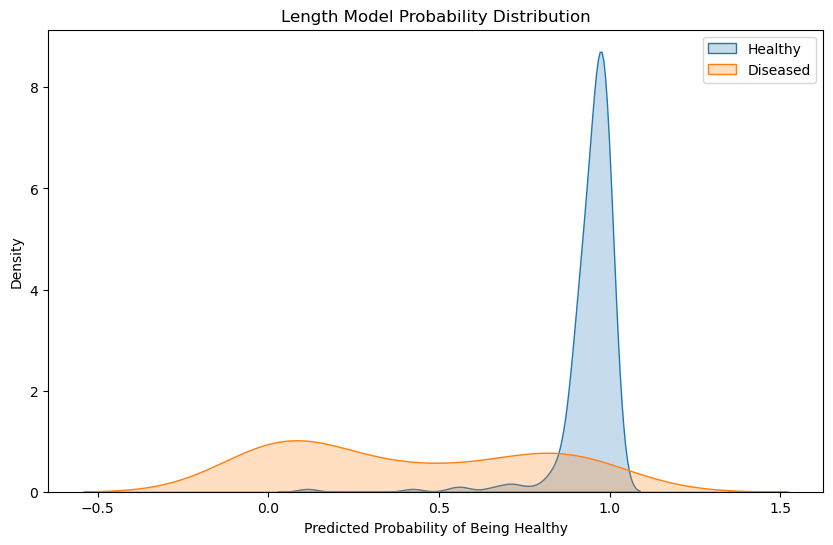

In [75]:
# create probabilkity output for all samples
y_length_prob_all = model_length.predict_proba(X_length)[:, 1]
df_length_colorectal['length_prob'] = y_length_prob_all
res_length = df_length_colorectal[['disease', 'healthy', 'length_prob']]
# plot the probability distributions for healthy vs diseased
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(res_length[res_length['disease'] == 'Healthy']['length_prob'], label='Healthy', shade=True)
sns.kdeplot(res_length[res_length['disease'] != 'Healthy']['length_prob'], label='Diseased', shade=True)
plt.title('Length Model Probability Distribution')
plt.xlabel('Predicted Probability of Being Healthy')
plt.ylabel('Density')
plt.legend()

## PFE

In [76]:
# # load
# df = pd.read_csv(pfe_path)
# df_pfe = df.drop(columns=['seqrun_id']).set_index('sample_id')
# X_pfe = df_pfe.drop(columns=metadata_cols)
# y_pfe = df_pfe['disease']

In [77]:
# # preprocessing:
# # standardize and GC correct
# matrix_processor = MatrixProcessor(mx = X_pfe, gc_file=gc_content)
# X_pfe = matrix_processor.process()

## EDM


In [78]:
df = pd.read_csv(edm_path)
df_edm = df.drop(columns=['seqrun_id']).set_index('sample_id')
df_edm['healthy'] = df_edm['disease'].apply(lambda x: 1 if x == 'Healthy' else 0)
X_edm = df_edm.drop(columns=metadata_cols)
y_edm = df_edm['healthy']

X_edm_train, X_edm_test, y_edm_train, y_edm_test = train_test_split(X_edm, y_edm, test_size=0.2, random_state=3)


In [79]:
model_edm = svm.SVC(random_state=7, probability=True)
model_edm.fit(X_edm_train, y_edm_train)
# evaluate
accuracy_edm = model_edm.score(X_edm_test, y_edm_test)
print(f"EDM model accuracy: {accuracy_edm:.4f}")
# auc
y_edm_prob = model_edm.predict_proba(X_edm_test)[:, 1]
auc_edm = roc_auc_score(y_edm_test, y_edm_prob)
print(f"EDM model AUC: {auc_edm:.4f}")

EDM model accuracy: 0.6739
EDM model AUC: 0.7929


In [80]:
# Filter to only healthy samples
df_healthy = df_edm[df_edm['disease'] == 'Healthy']

# Calculate mean for each feature column (excluding metadata)
feature_cols = [col for col in df_healthy.columns if col.startswith('edm_chr')]
healthy_means = df_healthy[feature_cols].mean().sort_values(ascending=False)

print("Most common motifs in healthy samples:")
print(healthy_means.head(10))

print("\nLeast common motifs in healthy samples:")
print(healthy_means.tail(10))

Most common motifs in healthy samples:
edm_chr19_bin_CCCA    0.029901
edm_chr19_bin_CCTG    0.028243
edm_chr22_bin_CCTG    0.027674
edm_chr22_bin_CCCA    0.027034
edm_chr17_bin_CCCA    0.025856
edm_chr17_bin_CCTG    0.025206
edm_chr22_bin_CCAG    0.024936
edm_chr19_bin_CCAG    0.024926
edm_chr16_bin_CCCA    0.024733
edm_chr20_bin_CCTG    0.024709
dtype: float64

Least common motifs in healthy samples:
edm_chr8_bin_ATCG     0.000134
edm_chr20_bin_ATCG    0.000133
edm_chr14_bin_ATCG    0.000132
edm_chr12_bin_ATCG    0.000131
edm_chr18_bin_ATCG    0.000130
edm_chr11_bin_ATCG    0.000129
edm_chr9_bin_ATCG     0.000128
edm_chr5_bin_ATCG     0.000126
edm_chr3_bin_ATCG     0.000123
edm_chr2_bin_ATCG     0.000120
dtype: float64


In [81]:
df_cancer = df_edm[df_edm['disease'] != 'Healthy']
cancer_means = df_cancer[feature_cols].mean().sort_values(ascending=False)

# See what changes
difference = cancer_means - healthy_means
print("\nBiggest increases in cancer:")
print(difference.sort_values(ascending=False).head(10))

print("\nBiggest decreases in cancer:")
print(difference.sort_values(ascending=True).head(10))


Biggest increases in cancer:
edm_chr4_bin_CATT     0.001098
edm_chr4_bin_TTCC     0.001045
edm_chr19_bin_CTGG    0.000967
edm_chr22_bin_CTGG    0.000893
edm_chr17_bin_CTGG    0.000867
edm_chr13_bin_ACTT    0.000830
edm_chr20_bin_CTGG    0.000827
edm_chr16_bin_CTGG    0.000816
edm_chr9_bin_CTGG     0.000812
edm_chr6_bin_ACTT     0.000801
dtype: float64

Biggest decreases in cancer:
edm_chr19_bin_CCCA   -0.001930
edm_chr17_bin_CCCA   -0.001669
edm_chr22_bin_CCCA   -0.001583
edm_chr16_bin_CCCA   -0.001553
edm_chr7_bin_CCCA    -0.001457
edm_chr10_bin_CCCA   -0.001455
edm_chr1_bin_CCCA    -0.001452
edm_chr20_bin_CCCA   -0.001444
edm_chr12_bin_CCCA   -0.001438
edm_chr8_bin_CCCA    -0.001435
dtype: float64
